
# Bagging

**Bagging**, or **Bootstrap Aggregating**, is a type of ensemble method that improves the stability and accuracy of machine learning algorithms by training multiple models on different subsets randomly sampled (with replacement) from the training data and then aggregating their predictions.

The main steps involved in bagging are:

1.  **Bootstrap Sampling**: Create multiple bootstrap samples from the original training dataset. Each bootstrap sample is created by randomly selecting instances from the original dataset with replacement, meaning some instances may appear multiple times while others may not appear at all.
2.  **Model Training**: Train a separate model on each bootstrap sample. This can be any machine learning algorithm, but decision trees are commonly used due to their high variance and low bias.
3.  **Aggregation**: For regression tasks, the predictions from all models are averaged to produce the final prediction. For classification tasks, a majority vote is taken among the predictions of all models to determine the final class label.
4.  **Final Prediction**: The aggregated prediction is then used as the final output of the bagging ensemble.

## Advantages and Disadvantages

Bagging has several advantages and disadvantages that make it suitable for various machine learning tasks:

-   **Advantages**:
    -   Can reduce variance and help prevent overfitting by averaging predictions from multiple models.
    -   Can improve accuracy, especially with high-variance models like decision trees.
    -   Robust to noise and outliers, as the aggregation process smooths out individual model errors.
    -   Can be parallelized, as each model can be trained independently on its bootstrap sample, making it efficient for large datasets.
-   **Disadvantages**:
    -   Requires more computational resources due to training multiple models.
    -   May not significantly improve performance if the base model is already stable and has low variance.

### Example

We will illustrate the concept of bagging using a simple example with a synthetic dataset. We will compare the performance of a single `DecisionTreeClassifier` model with a Bagging Classifier that uses the same model as its base estimator.

-   Generate a synthetic dataset

In [1]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, random_state=42)

-   Split the dataset into training and testing sets

In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=42)

-   Train a single DecisionTreeClassifier model

In [3]:
from sklearn.tree import DecisionTreeClassifier
single_model = DecisionTreeClassifier(random_state=42)
single_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

-   Evaluate the single model

In [4]:
single_accuracy = single_model.score(X_test, y_test)
print(f"Single DecisionTreeClassifier Accuracy: {single_accuracy:.2f}")

Single DecisionTreeClassifier Accuracy: 0.90


-   Train a Bagging model with DecisionTreeClassifier as estimator

In [5]:
from sklearn.ensemble import BaggingClassifier
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(),
                                  n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


-   Evaluate the model

In [6]:
accuracy = bagging_model.score(X_test, y_test)
print(f"Bagging Classifier Accuracy: {accuracy:.2f}")

Bagging Classifier Accuracy: 0.92


The Bagging Classifier typically achieves higher accuracy than the single Decision Tree model due to the reduction in variance and improved generalization.

## Random Forests

**Random Forests** is a popular ensemble method that uses bagging with decision trees as base models. It introduces additional randomness by selecting a random subset of features for each split in the decision tree, which helps to decorrelate the trees and further reduce overfitting.

This method combines the strengths of bagging and decision trees, resulting in a powerful and flexible model that can handle both classification and regression tasks effectively.

### Example: Random Forest Classifier on the Titanic Dataset

To illustrate the use of Random Forest, we will use the Titanic dataset and apply a Random Forest classifier. We will compare its performance with a single decision tree classifier to highlight the benefits of bagging.

-   Load the Titanic dataset

In [7]:
import pandas as pd
from sklearn.datasets import fetch_openml

data = fetch_openml('titanic', version=1, as_frame=True)
df = data.frame

df_sub = df[['pclass', 'sex', 'age', 'survived']].copy()

X = df_sub.drop('survived', axis=1)
y = df_sub['survived']

-   Split the dataset into training and testing sets

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")
print(f"Features: {X_train.columns.tolist()}")

Training set size: 916, Test set size: 393
Features: ['pclass', 'sex', 'age']


-   Preprocess the data

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Create a preprocessing pipeline
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('age', Pipeline(
            steps=[
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())
            ]
        ), ['age']),
        ('sex', Pipeline(steps=[
            ('encoder', OneHotEncoder(drop='first', sparse_output=False))
        ]), ['sex']),
        ('pclass', Pipeline(steps=[
            ('encoder', OneHotEncoder(sparse_output=False))
        ]), ['pclass'])
    ],
    remainder='passthrough'
)

# Fit and transform the data
X_train_transformed = preprocessing_pipeline.fit_transform(X_train)
X_test_transformed = preprocessing_pipeline.transform(X_test)

-   Train a single Decision Tree classifier with hyperparameter tuning

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Train a single Decision Tree classifier
single_tree_model = DecisionTreeClassifier(random_state=42)
grid_params = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform grid search for hyperparameter tuning
grid_search = GridSearchCV(single_tree_model, grid_params, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_transformed, y_train)
single_tree_model = grid_search.best_estimator_
single_tree_model.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

-   Evaluate the single model

Single Decision Tree Classifier Accuracy: 0.76
Feature Importances from Single Decision Tree:
sex__sex_male       0.580959
pclass__pclass_3    0.226990
age__age            0.147395
pclass__pclass_1    0.042398
pclass__pclass_2    0.002258
dtype: float64


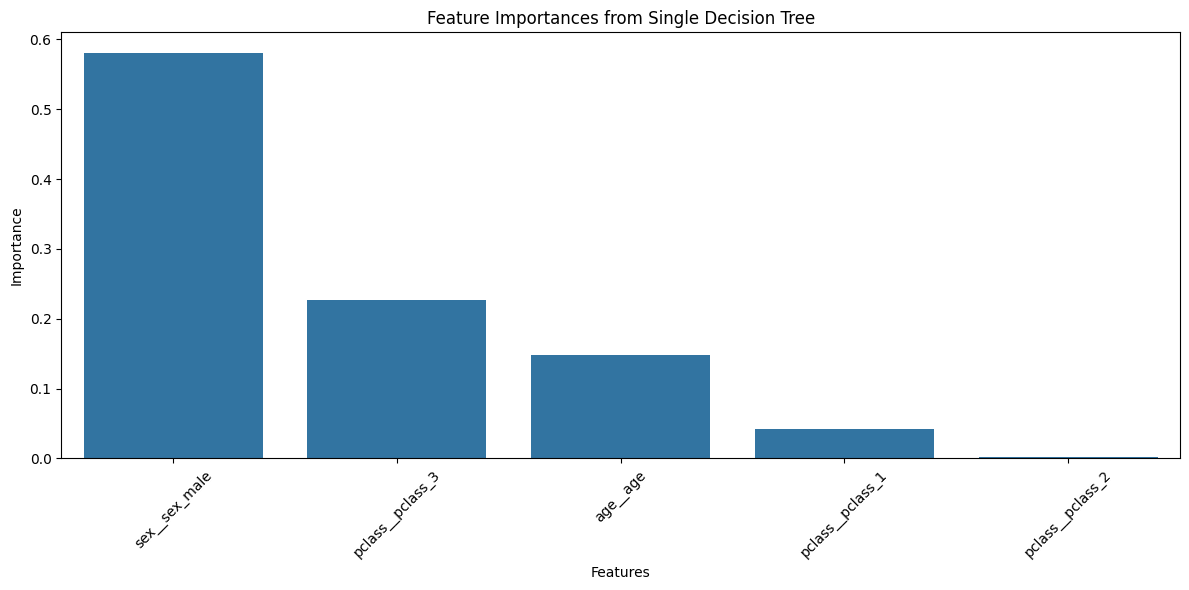

In [11]:
single_tree_accuracy = single_tree_model.score(X_test_transformed, y_test)
print(f"Single Decision Tree Classifier Accuracy: {single_tree_accuracy:.2f}")

# Feature importances
single_tree_importances = single_tree_model.feature_importances_
st_indices = single_tree_importances.argsort()[::-1]

feature_names = preprocessing_pipeline.get_feature_names_out()
feature_importances = pd.Series(single_tree_importances, index=feature_names)
print("Feature Importances from Single Decision Tree:")
print(feature_importances.sort_values(ascending=False))

# Plot feature importances
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances.sort_values(ascending=False).index,
            y=feature_importances.sort_values(ascending=False).values)
plt.title('Feature Importances from Single Decision Tree')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

-   Train a Random Forest classifier with hyperparameter tuning

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform grid search for hyperparameter tuning
rf_grid_search = GridSearchCV(rf_model, rf_grid_params, cv=5, n_jobs=-1, verbose=1)
rf_grid_search.fit(X_train_transformed, y_train)
rf_model = rf_grid_search.best_estimator_
rf_model.fit(X_train_transformed, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

-   Evaluate the Random Forest model

Random Forest Classifier Accuracy: 0.77
Feature Importances from Random Forest:
sex__sex_male       0.528668
age__age            0.232155
pclass__pclass_3    0.112150
pclass__pclass_1    0.102198
pclass__pclass_2    0.024828
dtype: float64


<Axes: xlabel='Feature'>

<Figure size 1200x600 with 0 Axes>

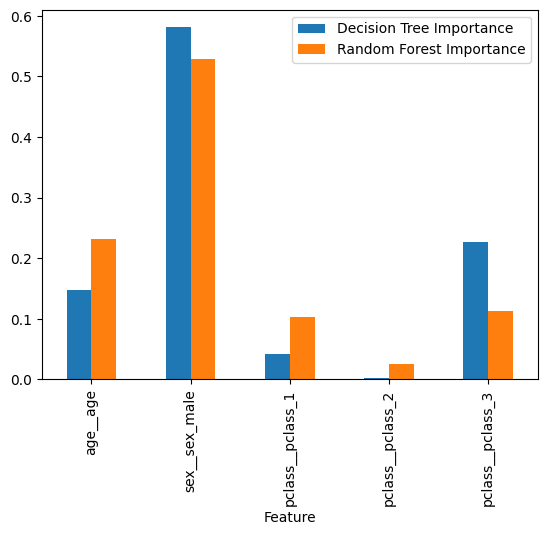

In [13]:
rf_accuracy = rf_model.score(X_test_transformed, y_test)
print(f"Random Forest Classifier Accuracy: {rf_accuracy:.2f}")

# Feature importances
rf_importances = rf_model.feature_importances_
rf_feature_importances = pd.Series(rf_importances, index=feature_names)
print("Feature Importances from Random Forest:")
print(rf_feature_importances.sort_values(ascending=False))

# Create a dataframe for feature importances
feature_importances = pd.DataFrame({
    'Feature': feature_names,
    'Decision Tree Importance': single_tree_importances,
    'Random Forest Importance': rf_importances
}).set_index('Feature')

# Compare feature importances
import matplotlib.pyplot as plt
import seaborn as sns

# Plot feature importances from Random Forest and Single Decision Tree in a stacked bar chart
plt.figure(figsize=(12, 6))
feature_importances.plot(kind='bar', stacked=False)

## Hands-on Exercises

**Bagging with Different Base Models**: Implement bagging using different base models (e.g., logistic regression, SVM) and compare their performance on a classification dataset (e.g., `iris`).

-   Load the dataset

In [14]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data[:,:2]
y_iris = iris.target

# Split the dataset into training and testing sets
X_train_iris, X_test_iris, y_train_iris, y_test_iris = \
    train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)
print(f"Training set size: {X_train_iris.shape[0]}, Test set size: {X_test_iris.shape[0]}")
print(f"Features: {iris.feature_names[:2]}")

Training set size: 105, Test set size: 45
Features: ['sepal length (cm)', 'sepal width (cm)']


-   Train a Bagging Classifier with Logistic Regression as the base model

In [15]:
from sklearn.linear_model import LogisticRegression

# Train a Bagging Classifier with Logistic Regression as the base model
bagging_logistic = BaggingClassifier(estimator=LogisticRegression(),
                                     n_estimators=100, random_state=42)
bagging_logistic.fit(X_train_iris, y_train_iris)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegression()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


-   Evaluate the Bagging Classifier with Logistic Regression and visualize the results

Bagging Classifier with Logistic Regression Accuracy: 0.82


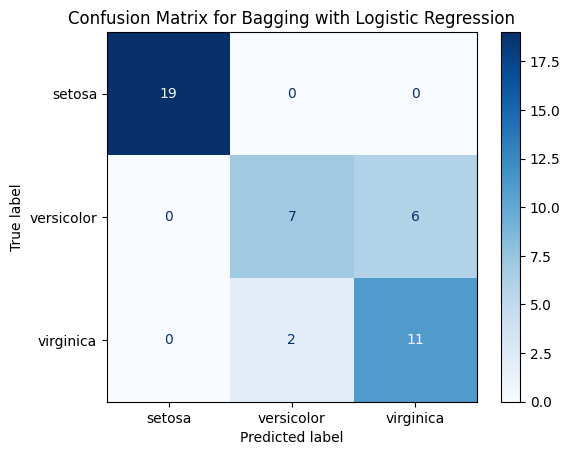

<Figure size 1000x600 with 0 Axes>

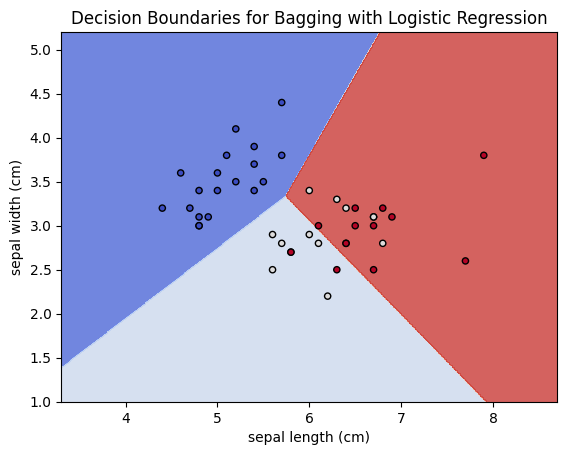

In [16]:
# Evaluate the model
logistic_accuracy = bagging_logistic.score(X_test_iris, y_test_iris)
print(f"Bagging Classifier with Logistic Regression Accuracy: {logistic_accuracy:.2f}")
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_logistic = bagging_logistic.predict(X_test_iris)
ConfusionMatrixDisplay.from_estimator(
    bagging_logistic, X_test_iris, y_test_iris,
    display_labels=iris.target_names, cmap='Blues')
plt.title('Confusion Matrix for Bagging with Logistic Regression')
plt.show()

# Plot decision boundaries
from sklearn.inspection import DecisionBoundaryDisplay
plt.figure(figsize=(10, 6))
DecisionBoundaryDisplay.from_estimator(
    bagging_logistic, X_train_iris, response_method='predict',
    grid_resolution=500, cmap=plt.cm.coolwarm, alpha=0.8,
    xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
plt.scatter(X_test_iris[:, 0], X_test_iris[:, 1], c=y_test_iris, edgecolor='k', s=20,
            cmap=plt.cm.coolwarm)
plt.title('Decision Boundaries for Bagging with Logistic Regression')
plt.show()

-   Train a Bagging Classifier with SVM as the base model and hyperparameter tuning

In [17]:
from sklearn.svm import SVC

# Train a Bagging Classifier with SVM as the base model
from sklearn.model_selection import GridSearchCV
svm_model = SVC(probability=True)
svm_grid_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
# Perform grid search for hyperparameter tuning
svm_grid_search = GridSearchCV(svm_model, svm_grid_params, cv=5, n_jobs=-1, verbose=1)
svm_grid_search.fit(X_train_iris, y_train_iris)
print("Best parameters for SVM Bagging Classifier:", svm_grid_search.best_params_)
# Use the best estimator from grid search
bagging_svm = svm_grid_search.best_estimator_
bagging_svm.fit(X_train_iris, y_train_iris)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for SVM Bagging Classifier: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


-   Evaluate the model and visualize the results

Bagging Classifier with SVM Accuracy: 0.82


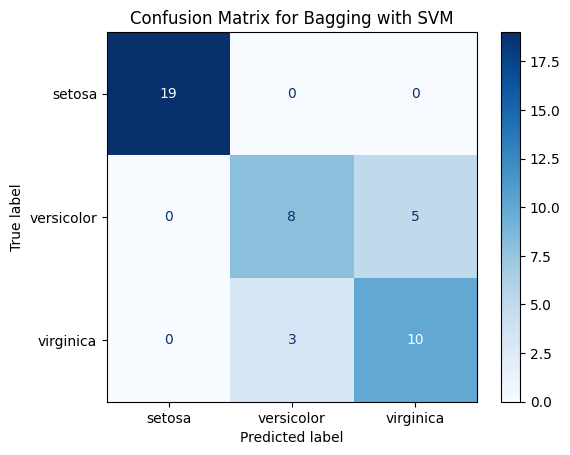

<Figure size 1000x600 with 0 Axes>

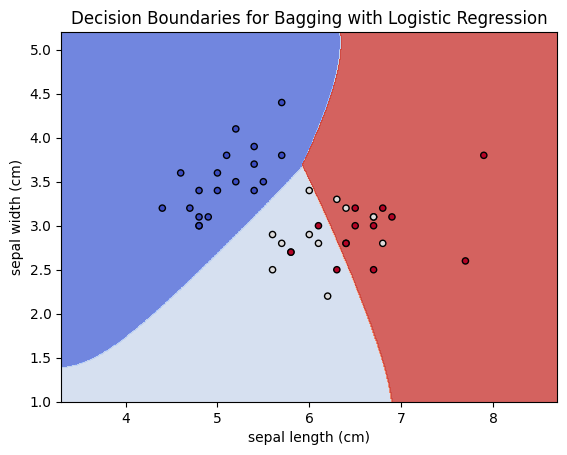

In [18]:
svm_accuracy = bagging_svm.score(X_test_iris, y_test_iris)
print(f"Bagging Classifier with SVM Accuracy: {svm_accuracy:.2f}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_svm = bagging_svm.predict(X_test_iris)
ConfusionMatrixDisplay.from_estimator(
    bagging_svm, X_test_iris, y_test_iris,
    display_labels=iris.target_names, cmap='Blues')
plt.title('Confusion Matrix for Bagging with SVM')
plt.show()

# Plot decision boundaries
from sklearn.inspection import DecisionBoundaryDisplay
plt.figure(figsize=(10, 6))
DecisionBoundaryDisplay.from_estimator(
    bagging_svm, X_train_iris, response_method='predict',
    grid_resolution=500, cmap=plt.cm.coolwarm, alpha=0.8,
    xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
plt.scatter(X_test_iris[:, 0], X_test_iris[:, 1], c=y_test_iris, edgecolor='k', s=20,
            cmap=plt.cm.coolwarm)
plt.title('Decision Boundaries for Bagging with Logistic Regression')
plt.show()